In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from collections import defaultdict

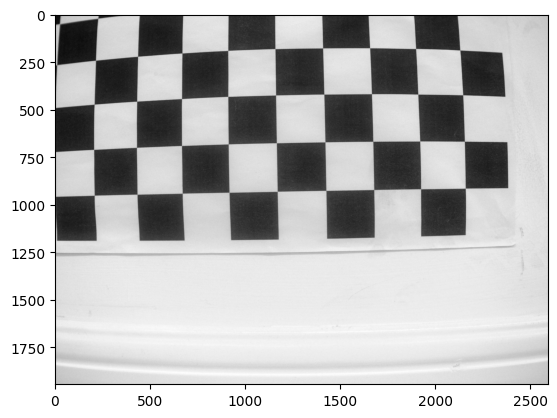

In [2]:
img = cv2.imread("test.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

In [3]:
roi_img = img[469:682, 439:658]
pixels = roi_img.flatten()

mean = np.mean(pixels)
std = np.std(pixels)
var = np.var(pixels)
print(mean, std, var)

93.94541985551054 4.61510390590045 21.299184062257588


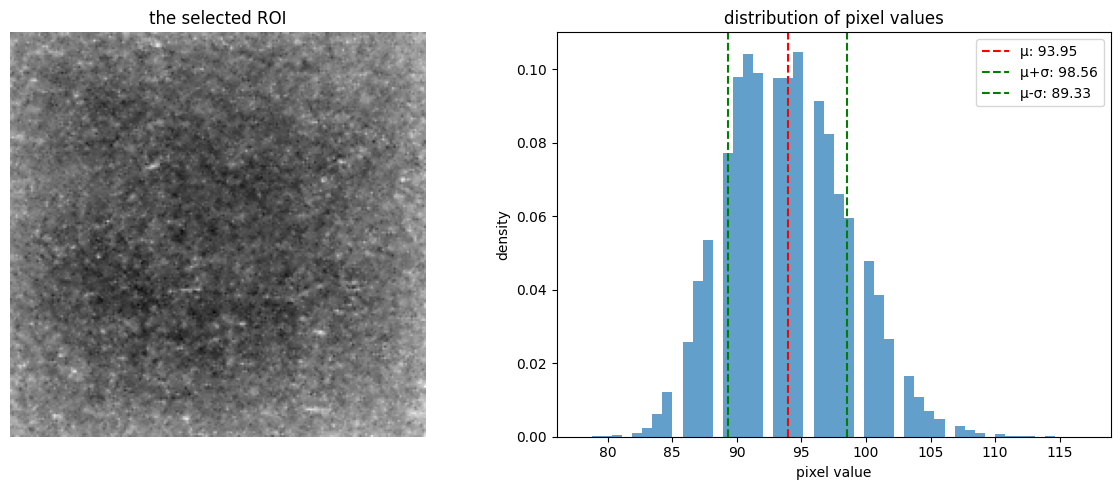

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(roi_img, cmap='gray')
plt.title("the selected ROI")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(pixels, bins=50, density=True, alpha=0.7)
plt.axvline(mean, color='r', linestyle='--', label=f"μ: {mean:.2f}")
plt.axvline(mean + std, color='g', linestyle='--', label=f"μ+σ: {mean+std:.2f}")
plt.axvline(mean - std, color='g', linestyle='--', label=f"μ-σ: {mean-std:.2f}")
plt.xlabel("pixel value")
plt.ylabel("density")
plt.title("distribution of pixel values")
plt.legend()

plt.tight_layout()
plt.show()

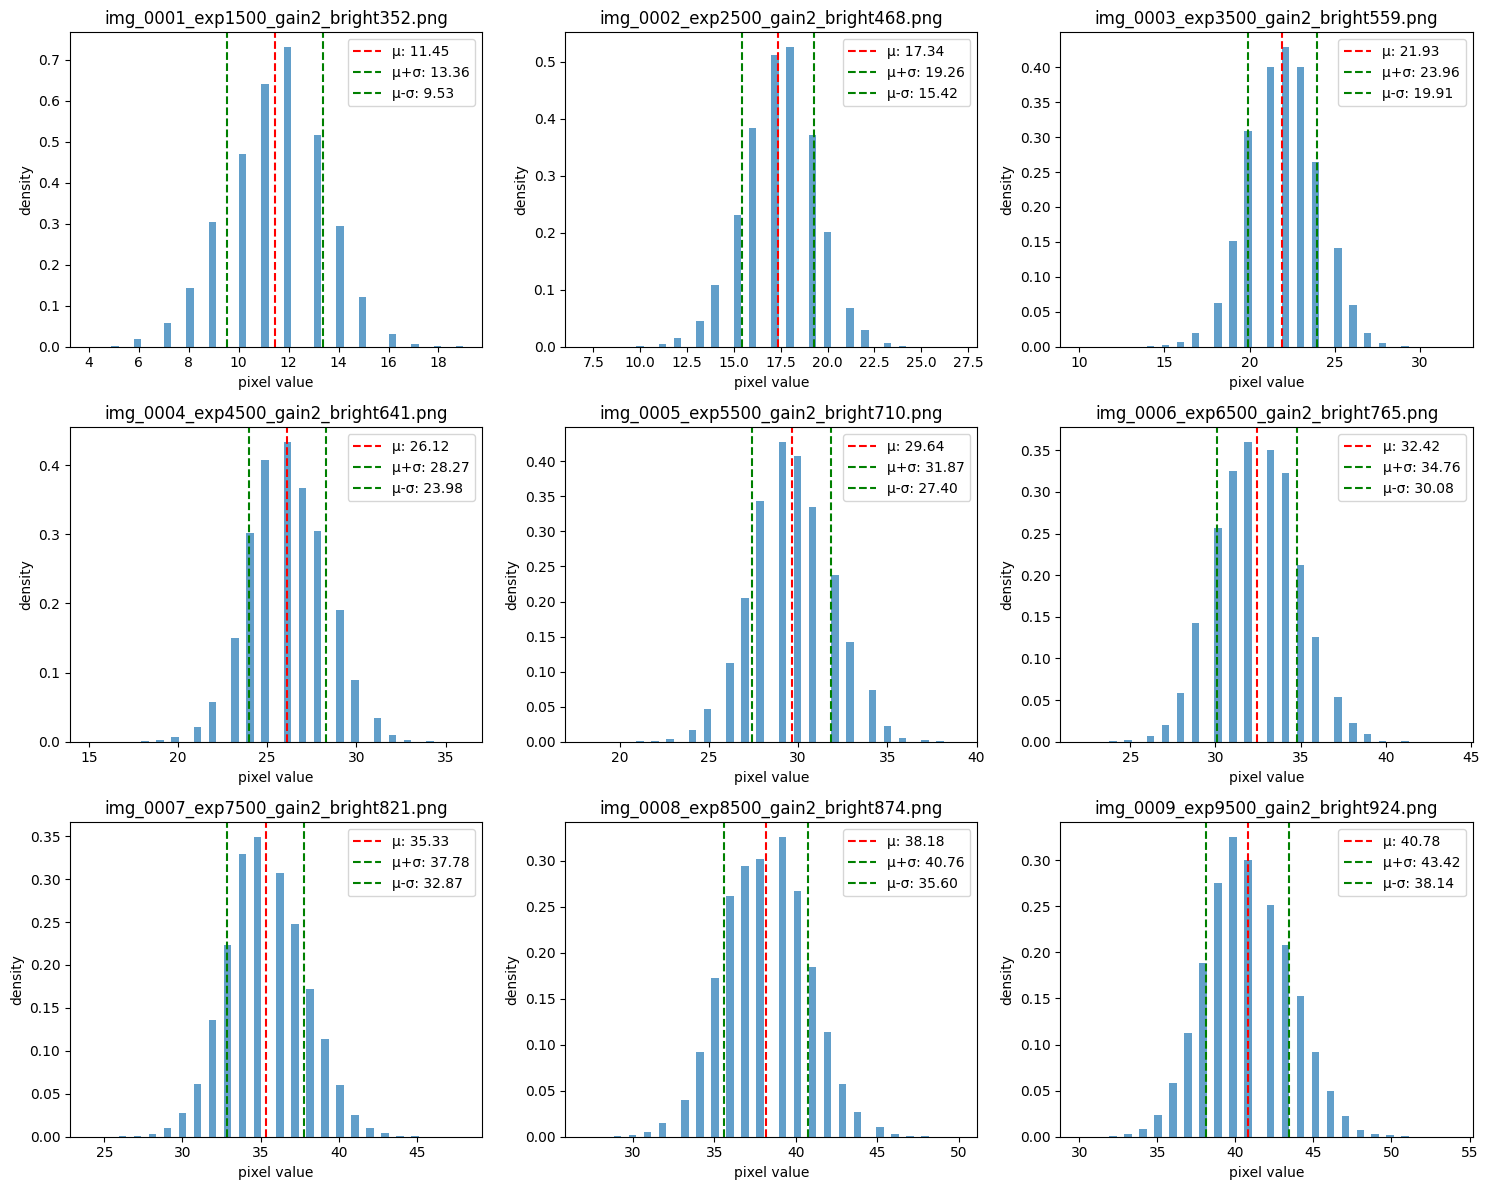

In [15]:
folder_path = r"capture_2025-09-19_15-53\\group1_iso_vary_exposure"
image_list = os.listdir(folder_path)
selected_images = image_list[1:10]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, image_file in enumerate(selected_images):
    image_path = os.path.join(folder_path, image_file)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    roi_img = img[469:682, 439:658]
    pixels = roi_img.flatten()

    mean = np.mean(pixels)
    std = np.std(pixels)
    var = np.var(pixels)
    
    plt.subplot(3,3,i+1)
    plt.hist(pixels, bins=50, density=True, alpha=0.7)
    plt.axvline(mean, color='r', linestyle='--', label=f"μ: {mean:.2f}")
    plt.axvline(mean + std, color='g', linestyle='--', label=f"μ+σ: {mean+std:.2f}")
    plt.axvline(mean - std, color='g', linestyle='--', label=f"μ-σ: {mean-std:.2f}")
    plt.xlabel("pixel value")
    plt.ylabel("density")
    plt.title(image_file)
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_params(filename):
    """
    img_XXXX_expXXXX_gainX_brightXXX.png
    """
    exp_match = re.search(r'exp(\d+)', filename)
    gain_match = re.search(r'gain(\d+)', filename)
    bright_match = re.search(r'bright(\d+)', filename)
    
    exposure = int(exp_match.group(1)) if exp_match else 0
    gain = int(gain_match.group(1)) if gain_match else 0
    bright = int(bright_match.group(1)) if bright_match else 0
    
    return exposure, gain, bright

In [ ]:
def analyze_noise(img_path, roi_coords):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    y1, y2, x1, x2 = roi_coords
    roi_img = img[y1:y2, x1:x2]
    pixels = roi_img.flatten()

    mean_val = np.mean(pixels)
    std_val = np.std(pixels)
    var_val = np.var(pixels)
    
    return mean_val, std_val, var_val

In [ ]:
def process_plot(folder_path):
    
    exposures = []
    gains = []
    brights = []
    means = []
    stds = []
    vars_ = []
    filenames = []

    roi_coords = (469, 682, 439, 658)
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.png'):
            img_path = os.path.join(folder_path, filename)
            exposure, gain, bright = get_params(filename)
            mean_val, std_val, var_val = analyze_noise(img_path, roi_coords)
            
            if mean_val is not None:
                exposures.append(exposure)
                gains.append(gain)
                brights.append(bright)
                means.append(mean_val)
                stds.append(std_val)
                vars_.append(var_val)
                filenames.append(filename)
                print(f"{filename} - mean: {mean_val:.2f}, standard deviation: {std_val:.2f}, variance: {var_val:.2f}")
    
    exposures = np.array(exposures)
    gains = np.array(gains)
    brights = np.array(brights)
    means = np.array(means)
    stds = np.array(stds)
    vars_ = np.array(vars_)
    
    plt.figure(figsize=(20, 15))
    
    # 1. 噪声均值与曝光时间的关系
    plt.subplot(4, 3, 1)
    plt.scatter(exposures, means, alpha=0.6)
    plt.xlabel('Exposure Time')
    plt.ylabel('Mean (Signal Strength)')
    plt.title('Mean vs Exposure Time')
    plt.grid(True)
    
    # 2. 噪声标准差与曝光时间的关系
    plt.subplot(4, 3, 2)
    plt.scatter(exposures, stds, alpha=0.6, color='orange')
    plt.xlabel('Exposure Time')
    plt.ylabel('Standard Deviation (Noise Level)')
    plt.title('Standard Deviation vs Exposure Time')
    plt.grid(True)
    
    # 3. 噪声方差与曝光时间的关系
    plt.subplot(4, 3, 3)
    plt.scatter(exposures, vars_, alpha=0.6, color='red')
    plt.xlabel('Exposure Time')
    plt.ylabel('Variance')
    plt.title('Variance vs Exposure Time')
    plt.grid(True)
    
    
    # 4. 噪声均值与增益的关系
    plt.subplot(4, 3, 4)
    plt.scatter(gains, means, alpha=0.6, color='green')
    plt.xlabel('Gain')
    plt.ylabel('Mean (Signal Strength)')
    plt.title('Mean vs Gain')
    plt.grid(True)
    
    # 5. 噪声标准差与增益的关系
    plt.subplot(4, 3, 5)
    plt.scatter(gains, stds, alpha=0.6, color='purple')
    plt.xlabel('Gain')
    plt.ylabel('Standard Deviation (Noise Level)')
    plt.title('Standard Deviation vs Gain')
    plt.grid(True)
    
    # 6. 噪声方差与增益的关系
    plt.subplot(4, 3, 6)
    plt.scatter(gains, vars_, alpha=0.6, color='brown')
    plt.xlabel('Gain')
    plt.ylabel('Variance')
    plt.title('Variance vs Gain')
    plt.grid(True)
    
    # 7. 均值、曝光时间、增益
    ax1 = plt.subplot(4, 3, 7, projection='3d')
    scatter1 = ax1.scatter(exposures, gains, means, c=means, cmap='viridis')
    ax1.set_xlabel('Exposure Time')
    ax1.set_ylabel('Gain')
    ax1.set_zlabel('Mean')
    ax1.set_title('Mean vs Exposure & Gain')
    plt.colorbar(scatter1, ax=ax1, shrink=0.5)

    # 8. 标准差、曝光时间、增益
    ax2 = plt.subplot(4, 3, 8, projection='3d')
    scatter2 = ax2.scatter(exposures, gains, stds, c=stds, cmap='plasma')
    ax2.set_xlabel('Exposure Time')
    ax2.set_ylabel('Gain')
    ax2.set_zlabel('Standard Deviation')
    ax2.set_title('Std vs Exposure & Gain')
    plt.colorbar(scatter2, ax=ax2, shrink=0.5)
    
    # 9. 方差、曝光时间、增益
    ax3 = plt.subplot(4, 3, 9, projection='3d')
    scatter3 = ax3.scatter(exposures, gains, vars_, c=vars_, cmap='inferno')
    ax3.set_xlabel('Exposure Time')
    ax3.set_ylabel('Gain')
    ax3.set_zlabel('Variance')
    ax3.set_title('Variance vs Exposure & Gain')
    plt.colorbar(scatter3, ax=ax3, shrink=0.5)

    # 10. 噪声均值与亮度的关系
    plt.subplot(4, 3, 10)
    plt.scatter(brights, means, alpha=0.6, color='cyan')
    plt.xlabel('Brightness')
    plt.ylabel('Mean (Signal Strength)')
    plt.title('Mean vs Brightness')
    plt.grid(True)

    # 11. 噪声标准差与亮度的关系
    plt.subplot(4, 3, 11)
    plt.scatter(brights, stds, alpha=0.6, color='magenta')
    plt.xlabel('Brightness')
    plt.ylabel('Standard Deviation (Noise Level)')
    plt.title('Std vs Brightness')
    plt.grid(True)
    
    # 12. 噪声方差与亮度的关系
    plt.subplot(4, 3, 12)
    plt.scatter(brights, vars_, alpha=0.6, color='olive')
    plt.xlabel('Brightness')
    plt.ylabel('Variance')
    plt.title('Variance vs Brightness')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    # 输出统计摘要
    print("\n=== 统计摘要 ===")
    print(f"处理图像总数: {len(exposures)}")
    print(f"曝光时间范围: {np.min(exposures)} - {np.max(exposures)}")
    print(f"增益范围: {np.min(gains)} - {np.max(gains)}")
    print(f"噪声均值范围: {np.min(means):.2f} - {np.max(means):.2f}")
    print(f"噪声标准差范围: {np.min(stds):.2f} - {np.max(stds):.2f}")
    print(f"噪声方差范围: {np.min(vars_):.2f} - {np.max(vars_):.2f}")
    
    return exposures, gains, means, stds, vars_

img_0000_exp500_gain2_bright170.png - mean: 3.93, standard deviation: 1.58, variance: 2.50
img_0001_exp1500_gain2_bright352.png - mean: 11.45, standard deviation: 1.92, variance: 3.67
img_0002_exp2500_gain2_bright468.png - mean: 17.34, standard deviation: 1.92, variance: 3.69
img_0003_exp3500_gain2_bright559.png - mean: 21.93, standard deviation: 2.02, variance: 4.09
img_0004_exp4500_gain2_bright641.png - mean: 26.12, standard deviation: 2.15, variance: 4.61
img_0005_exp5500_gain2_bright710.png - mean: 29.64, standard deviation: 2.23, variance: 4.99
img_0006_exp6500_gain2_bright765.png - mean: 32.42, standard deviation: 2.34, variance: 5.47
img_0007_exp7500_gain2_bright821.png - mean: 35.33, standard deviation: 2.46, variance: 6.03
img_0008_exp8500_gain2_bright874.png - mean: 38.18, standard deviation: 2.58, variance: 6.63
img_0009_exp9500_gain2_bright924.png - mean: 40.78, standard deviation: 2.64, variance: 6.98
img_0010_exp10500_gain2_bright963.png - mean: 41.88, standard deviation:

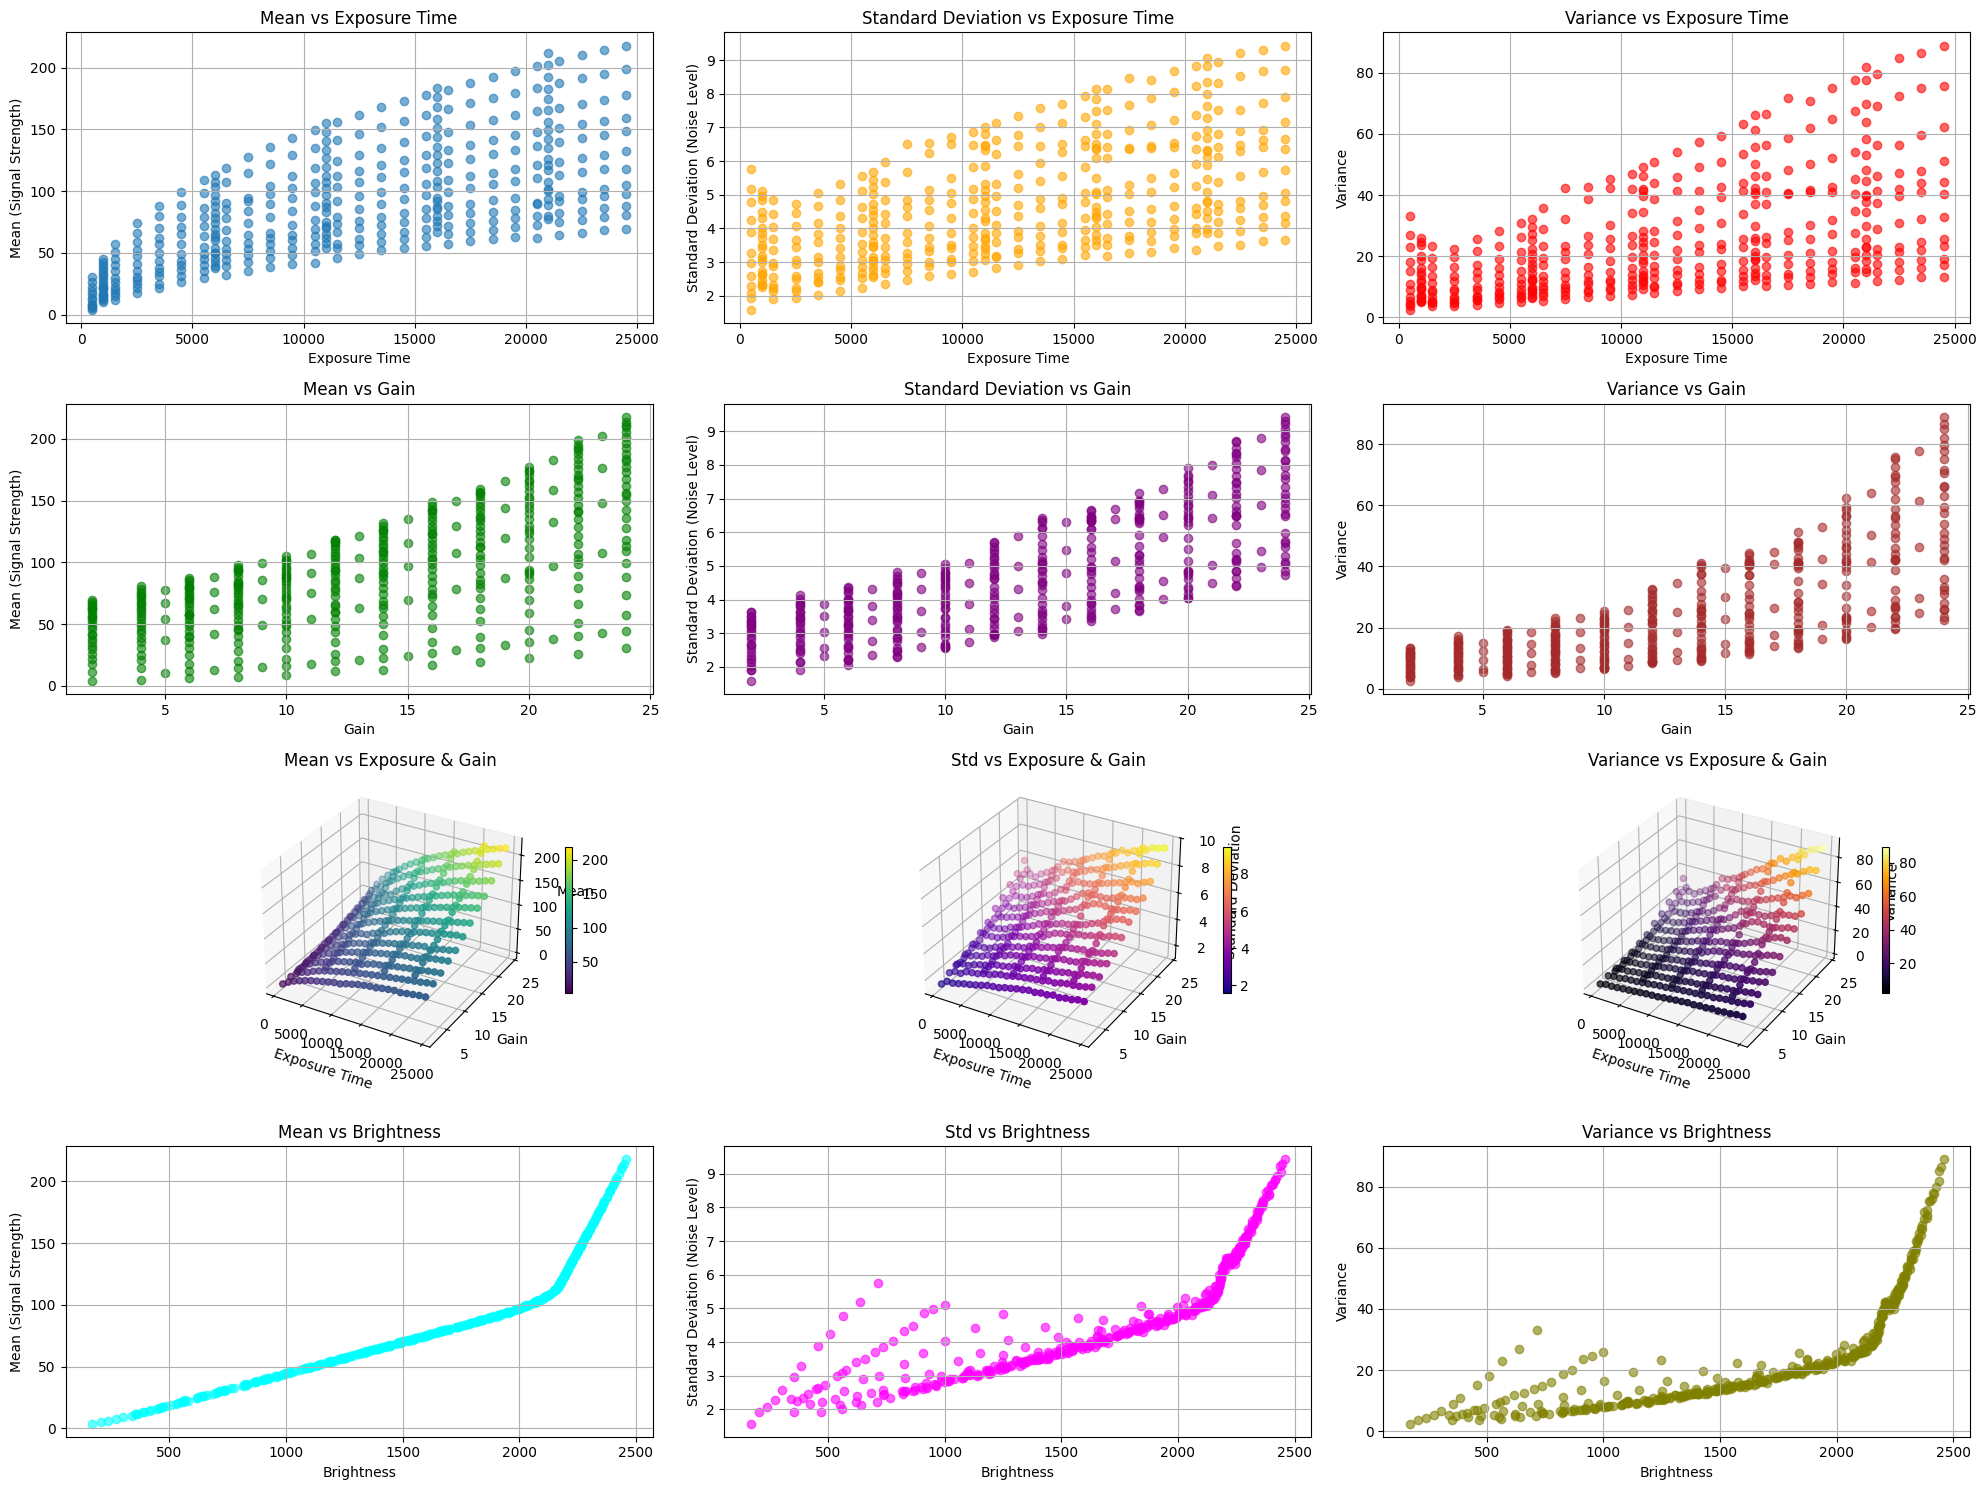


=== 统计摘要 ===
处理图像总数: 400
曝光时间范围: 500 - 24500
增益范围: 2 - 24
噪声均值范围: 3.93 - 217.86
噪声标准差范围: 1.58 - 9.43
噪声方差范围: 2.50 - 88.93


In [ ]:
folder_path = r"images"
exposures, gains, means, stds, vars_ = process_plot(folder_path)

In [ ]:
def analyze_exp_mean(file_path):
    exp_means = defaultdict(list)
    pattern = r"img_\d+_exp(\d+)_gain\d+_bright\d+\.png - mean: ([\d.]+),"

    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(pattern, line)
            if match:
                exp = int(match.group(1))
                mean = float(match.group(2))
                exp_means[exp].append(mean)
    
    # get exp-mean_average
    exp_mean_avg = {}
    for exp, means in exp_means.items():
        avg = sum(means) / len(means)
        exp_mean_avg[exp] = round(avg, 2)
    
    sorted_exps = sorted(exp_mean_avg.items())
    exps, mean_averages = zip(*sorted_exps) if sorted_exps else ([], [])
    for exp, avg in sorted_exps:
        print(f"exp: {exp}, mean_average: {avg}")
    for exp, avg in sorted_exps:
        print(f"{exp}\t{avg}")
    
    # exp-mean_average
    plt.figure(figsize=(10, 6))
    plt.plot(exps, mean_averages, 'o-', color='b')
    plt.title('exp-mean_average')
    plt.xlabel('exp')
    plt.ylabel('mean_average')
    plt.grid(True)
    plt.savefig('exp_mean_average.png')
    plt.show()
        
    return sorted_exps

exp: 500, mean_average: 14.27
exp: 1500, mean_average: 30.8
exp: 2500, mean_average: 41.38
exp: 3500, mean_average: 49.99
exp: 4500, mean_average: 57.15
exp: 5500, mean_average: 63.53
exp: 6500, mean_average: 68.91
exp: 7500, mean_average: 74.02
exp: 8500, mean_average: 78.95
exp: 9500, mean_average: 83.8
exp: 10500, mean_average: 88.11
exp: 11500, mean_average: 92.1
exp: 12500, mean_average: 96.32
exp: 13500, mean_average: 100.36
exp: 14500, mean_average: 103.81
exp: 15500, mean_average: 107.14
exp: 16500, mean_average: 110.21
exp: 17500, mean_average: 113.59
exp: 18500, mean_average: 116.54
exp: 19500, mean_average: 119.48
exp: 20500, mean_average: 121.6
exp: 21500, mean_average: 124.78
exp: 22500, mean_average: 127.56
exp: 23500, mean_average: 130.31
exp: 24500, mean_average: 132.69
500	14.27
1500	30.8
2500	41.38
3500	49.99
4500	57.15
5500	63.53
6500	68.91
7500	74.02
8500	78.95
9500	83.8
10500	88.11
11500	92.1
12500	96.32
13500	100.36
14500	103.81
15500	107.14
16500	110.21
17500	113

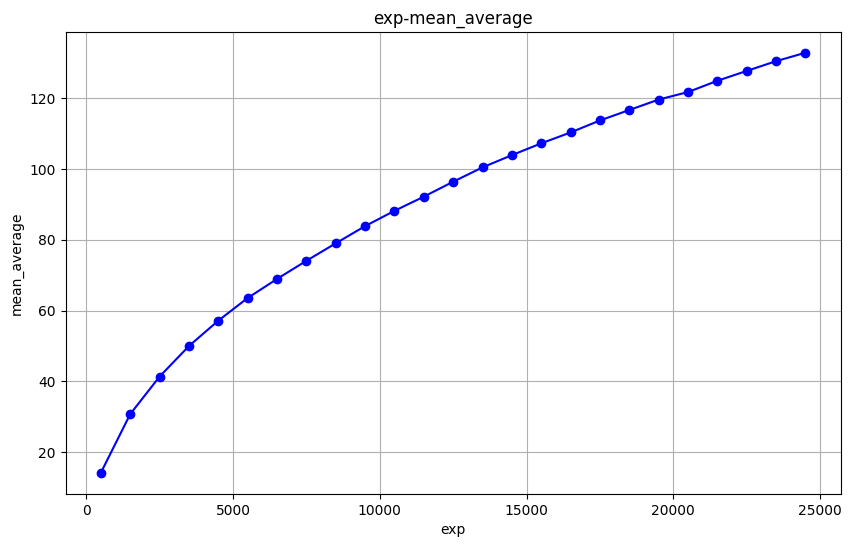

[(500, 14.27),
 (1500, 30.8),
 (2500, 41.38),
 (3500, 49.99),
 (4500, 57.15),
 (5500, 63.53),
 (6500, 68.91),
 (7500, 74.02),
 (8500, 78.95),
 (9500, 83.8),
 (10500, 88.11),
 (11500, 92.1),
 (12500, 96.32),
 (13500, 100.36),
 (14500, 103.81),
 (15500, 107.14),
 (16500, 110.21),
 (17500, 113.59),
 (18500, 116.54),
 (19500, 119.48),
 (20500, 121.6),
 (21500, 124.78),
 (22500, 127.56),
 (23500, 130.31),
 (24500, 132.69)]

In [9]:
analyze_exp_mean('output.txt')

In [ ]:
def analyze_gain_mean(file_path):
    gain_means = defaultdict(list)
    pattern = r"img_\d+_exp\d+_gain(\d+)_bright\d+\.png - mean: ([\d.]+),"

    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(pattern, line)
            if match:
                gain = int(match.group(1))
                mean = float(match.group(2))
                gain_means[gain].append(mean)
    
    # get gain-mean_average
    gain_mean_avg = {}
    for gain, means in gain_means.items():
        avg = sum(means) / len(means)
        gain_mean_avg[gain] = round(avg, 2)
    
    sorted_gains = sorted(gain_mean_avg.items())
    gains, mean_averages = zip(*sorted_gains) if sorted_gains else ([], [])
    
    for gain, avg in sorted_gains:
        print(f"gain: {gain}, mean_average: {avg}")
    for gain, avg in sorted_gains:
        print(f"{gain}\t{avg}")
    
    # gain-mean_average
    plt.figure(figsize=(10, 6))
    plt.plot(gains, mean_averages, 'o-', color='r')
    plt.title('gain-mean_average')
    plt.xlabel('gain')
    plt.ylabel('mean_average')
    plt.grid(True)
    plt.savefig('gain_mean_average.png')
    plt.show()
        
    return sorted_gains

gain值与对应的mean平均值：
gain: 5, mean_average: 49.21
gain: 6, mean_average: 52.11
gain: 7, mean_average: 56.33
gain: 8, mean_average: 59.84
gain: 9, mean_average: 64.18
gain: 10, mean_average: 65.33
gain: 11, mean_average: 69.22
gain: 12, mean_average: 74.93
gain: 13, mean_average: 79.36
gain: 14, mean_average: 82.54
gain: 15, mean_average: 88.28
gain: 16, mean_average: 93.66
gain: 17, mean_average: 98.68
gain: 18, mean_average: 103.45
gain: 19, mean_average: 109.91
gain: 20, mean_average: 116.0
gain: 21, mean_average: 121.78
gain: 22, mean_average: 129.0
gain: 23, mean_average: 135.24
gain: 24, mean_average: 141.54

表格格式输出：
5	49.21
6	52.11
7	56.33
8	59.84
9	64.18
10	65.33
11	69.22
12	74.93
13	79.36
14	82.54
15	88.28
16	93.66
17	98.68
18	103.45
19	109.91
20	116.0
21	121.78
22	129.0
23	135.24
24	141.54


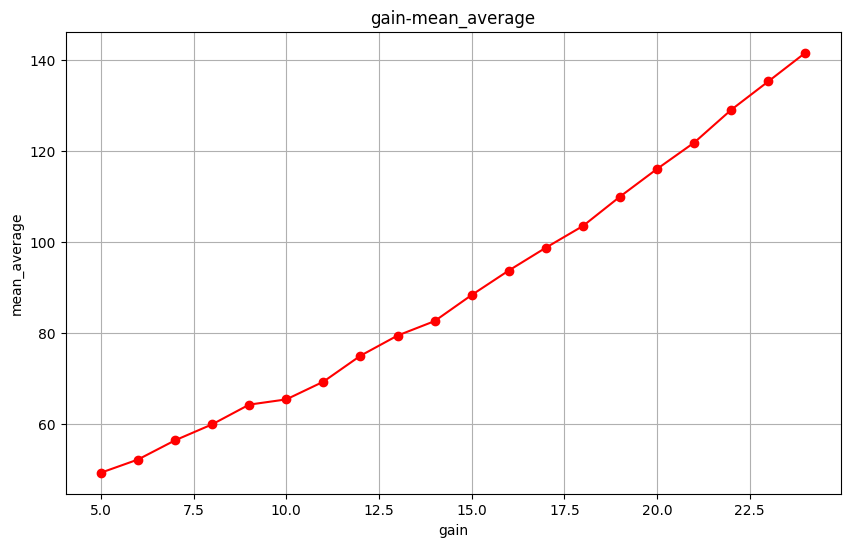

[(5, 49.21),
 (6, 52.11),
 (7, 56.33),
 (8, 59.84),
 (9, 64.18),
 (10, 65.33),
 (11, 69.22),
 (12, 74.93),
 (13, 79.36),
 (14, 82.54),
 (15, 88.28),
 (16, 93.66),
 (17, 98.68),
 (18, 103.45),
 (19, 109.91),
 (20, 116.0),
 (21, 121.78),
 (22, 129.0),
 (23, 135.24),
 (24, 141.54)]

In [12]:
analyze_gain_mean("output.txt")

In [ ]:
def analyze_gain_std(file_path):
    gain_stds = defaultdict(list)
    pattern = r"img_\d+_exp\d+_gain(\d+)_bright\d+\.png - mean: [\d.]+, standard deviation: ([\d.]+),"

    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(pattern, line)
            if match:
                gain = int(match.group(1))
                std = float(match.group(2))
                gain_stds[gain].append(std)
    
    gain_std_avg = {}
    for gain, stds in gain_stds.items():
        avg = sum(stds) / len(stds)
        gain_std_avg[gain] = round(avg, 2)
    
    sorted_gains = sorted(gain_std_avg.items())
    gains, std_averages = zip(*sorted_gains) if sorted_gains else ([], [])

    for gain, avg in sorted_gains:
        print(f"gain: {gain}, std_average: {avg}")
    for gain, avg in sorted_gains:
        print(f"{gain}\t{avg}")
    
    # gain-std_average
    plt.figure(figsize=(10, 6))
    plt.plot(gains, std_averages, 'o-', color='g')
    plt.title('gain-average_standard_deviation')
    plt.xlabel('gain')
    plt.ylabel('average standard deviation')
    plt.grid(True)
    plt.savefig('gain_std_average.png')
    plt.show()
        
    return sorted_gains

gain值与对应的标准差平均值：
gain: 5, std_average: 3.06
gain: 6, std_average: 3.15
gain: 7, std_average: 3.33
gain: 8, std_average: 3.48
gain: 9, std_average: 3.68
gain: 10, std_average: 3.71
gain: 11, std_average: 3.86
gain: 12, std_average: 4.15
gain: 13, std_average: 4.35
gain: 14, std_average: 4.5
gain: 15, std_average: 4.76
gain: 16, std_average: 4.98
gain: 17, std_average: 5.23
gain: 18, std_average: 5.37
gain: 19, std_average: 5.65
gain: 20, std_average: 5.96
gain: 21, std_average: 6.21
gain: 22, std_average: 6.48
gain: 23, std_average: 6.78
gain: 24, std_average: 6.99

表格格式输出：
5	3.06
6	3.15
7	3.33
8	3.48
9	3.68
10	3.71
11	3.86
12	4.15
13	4.35
14	4.5
15	4.76
16	4.98
17	5.23
18	5.37
19	5.65
20	5.96
21	6.21
22	6.48
23	6.78
24	6.99


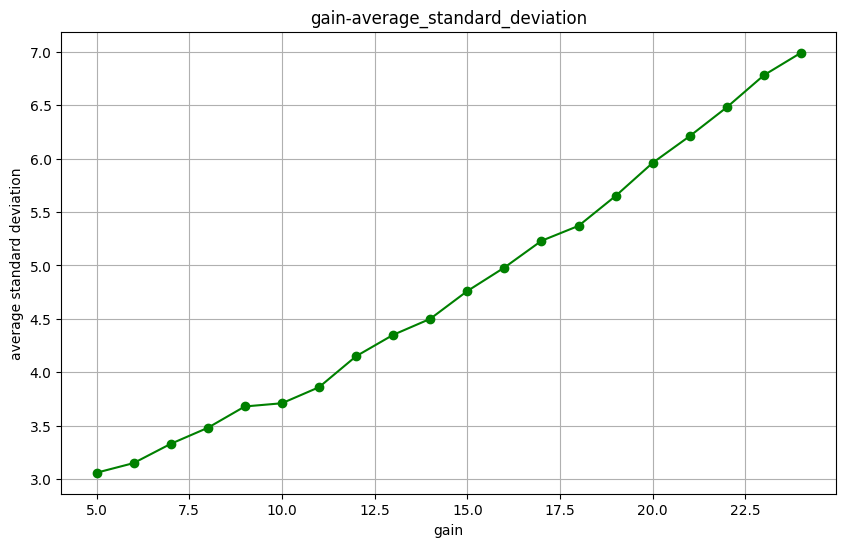

[(5, 3.06),
 (6, 3.15),
 (7, 3.33),
 (8, 3.48),
 (9, 3.68),
 (10, 3.71),
 (11, 3.86),
 (12, 4.15),
 (13, 4.35),
 (14, 4.5),
 (15, 4.76),
 (16, 4.98),
 (17, 5.23),
 (18, 5.37),
 (19, 5.65),
 (20, 5.96),
 (21, 6.21),
 (22, 6.48),
 (23, 6.78),
 (24, 6.99)]

In [18]:
analyze_gain_std("output.txt")

In [ ]:
def analyze_exp_std(file_path):
    exp_stds = defaultdict(list)
    pattern = r"img_\d+_exp(\d+)_gain\d+_bright\d+\.png - mean: [\d.]+, standard deviation: ([\d.]+),"

    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(pattern, line)
            if match:
                exp = int(match.group(1))
                std = float(match.group(2))
                exp_stds[exp].append(std)
    
    exp_std_avg = {}
    for exp, stds in exp_stds.items():
        avg = sum(stds) / len(stds)
        exp_std_avg[exp] = round(avg, 2)
    
    sorted_exps = sorted(exp_std_avg.items())
    exps, std_averages = zip(*sorted_exps) if sorted_exps else ([], [])
    
    for exp, avg in sorted_exps:
        print(f"exp: {exp}, std_average: {avg}")
    for exp, avg in sorted_exps:
        print(f"{exp}\t{avg}")
    
    # exp-std_average
    plt.figure(figsize=(10, 6))
    plt.plot(exps, std_averages, 'o-', color='purple')
    plt.title('exp-average_standard_deviation')
    plt.xlabel('exposure (exp)')
    plt.ylabel('average standard deviation')
    plt.grid(True)
    plt.savefig('exp_std_average.png')
    plt.show()
        
    return sorted_exps

exposure值与对应的标准差平均值：
exp: 500, std_average: 3.38
exp: 1500, std_average: 3.11
exp: 2500, std_average: 3.14
exp: 3500, std_average: 3.3
exp: 4500, std_average: 3.47
exp: 5500, std_average: 3.64
exp: 6500, std_average: 3.83
exp: 7500, std_average: 4.0
exp: 8500, std_average: 4.19
exp: 9500, std_average: 4.36
exp: 10500, std_average: 4.49
exp: 11500, std_average: 4.63
exp: 12500, std_average: 4.8
exp: 13500, std_average: 4.96
exp: 14500, std_average: 5.08
exp: 15500, std_average: 5.21
exp: 16500, std_average: 5.34
exp: 17500, std_average: 5.46
exp: 18500, std_average: 5.53
exp: 19500, std_average: 5.65
exp: 20500, std_average: 5.74
exp: 21500, std_average: 5.85
exp: 22500, std_average: 5.96
exp: 23500, std_average: 6.08
exp: 24500, std_average: 6.16

表格格式输出：
500	3.38
1500	3.11
2500	3.14
3500	3.3
4500	3.47
5500	3.64
6500	3.83
7500	4.0
8500	4.19
9500	4.36
10500	4.49
11500	4.63
12500	4.8
13500	4.96
14500	5.08
15500	5.21
16500	5.34
17500	5.46
18500	5.53
19500	5.65
20500	5.74
21500	5.85
22500	

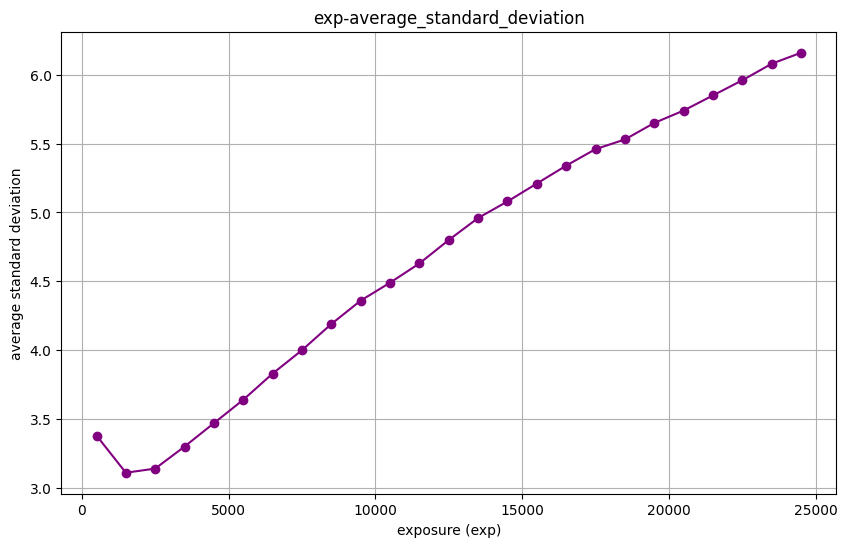

[(500, 3.38),
 (1500, 3.11),
 (2500, 3.14),
 (3500, 3.3),
 (4500, 3.47),
 (5500, 3.64),
 (6500, 3.83),
 (7500, 4.0),
 (8500, 4.19),
 (9500, 4.36),
 (10500, 4.49),
 (11500, 4.63),
 (12500, 4.8),
 (13500, 4.96),
 (14500, 5.08),
 (15500, 5.21),
 (16500, 5.34),
 (17500, 5.46),
 (18500, 5.53),
 (19500, 5.65),
 (20500, 5.74),
 (21500, 5.85),
 (22500, 5.96),
 (23500, 6.08),
 (24500, 6.16)]

In [17]:
analyze_exp_std("output.txt")